# Public Document Metadata Analysis

Analyze synthetic metadata fields that resemble openly published documents.

**Safety and scope:** This notebook uses deterministic synthetic data and makes no network requests. Its results are analytical leads, not attribution or identity claims.

## Goal

Group related production patterns and identify metadata-hygiene issues without exposing personal identifiers.


## Setup

The workflow runs offline with NumPy and Pandas. Parameters and source-like fields are visible so the analysis can be reviewed and rerun.

### Key Assumptions

- All records are synthetic and contain no real people or infrastructure.
- Scores prioritize review; they do not prove ownership, intent, identity, or location.
- Real use requires documented authority, provenance, source terms, and retention limits.


In [1]:
import numpy as np
import pandas as pd

SEED = 88
rng = np.random.default_rng(SEED)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 130)
pd.set_option("display.max_colwidth", 70)


## Steps

### 1. Create bounded synthetic observations


In [2]:
document_count = 80
documents = pd.DataFrame({
    "document_id": [f"doc-{index:03d}" for index in range(document_count)],
    "creator_tool": rng.choice(["Writer-A", "Writer-B", "PDF-Engine-C", "Scanner-D"], document_count),
    "template_id": rng.choice([f"template-{index:02d}" for index in range(10)], document_count),
    "timezone_offset": rng.choice([-8, -5, 0, 1, 5, 8], document_count),
    "revision_count": rng.integers(1, 24, document_count),
    "author_field_present": rng.binomial(1, 0.35, document_count),
})
print(documents.head(7).to_string(index=False))


document_id creator_tool template_id  timezone_offset  revision_count  author_field_present
    doc-000 PDF-Engine-C template-01                5               8                     1
    doc-001     Writer-A template-01                5              15                     0
    doc-002    Scanner-D template-04                8              10                     0
    doc-003 PDF-Engine-C template-06                0               3                     1
    doc-004 PDF-Engine-C template-04                0               4                     0
    doc-005 PDF-Engine-C template-03                5              13                     0
    doc-006    Scanner-D template-04                0              21                     0


### 2. Analyze and rank the observations


In [3]:
production_patterns = (
    documents.groupby(["creator_tool", "template_id"], as_index=False)
    .agg(documents=("document_id", "count"), timezones=("timezone_offset", "nunique"), author_fields=("author_field_present", "sum"), median_revisions=("revision_count", "median"))
)
production_patterns["metadata_hygiene_score"] = (
    1 - np.minimum(production_patterns["author_fields"] / production_patterns["documents"], 1)
).round(3)
ranked_patterns = production_patterns.sort_values(["documents", "metadata_hygiene_score"], ascending=[False, True])
print(ranked_patterns.head(10).to_string(index=False))


creator_tool template_id  documents  timezones  author_fields  median_revisions  metadata_hygiene_score
PDF-Engine-C template-05          5          3              2              17.0                   0.600
    Writer-B template-08          5          4              2              10.0                   0.600
    Writer-A template-05          4          4              3               7.0                   0.250
    Writer-A template-09          4          2              2               5.5                   0.500
   Scanner-D template-03          4          3              1               8.5                   0.750
    Writer-B template-01          4          4              1               5.0                   0.750
    Writer-B template-07          4          3              1              12.0                   0.750
PDF-Engine-C template-06          3          3              2               3.0                   0.333
PDF-Engine-C template-07          3          3              2   

## Visual Insights & ML Extension

This section adds a polished visual story and a project-appropriate machine-learning extension while preserving the original transparent score or aggregation. Supervised labels are synthetic evaluation aids; unsupervised clusters and anomalies are review leads only.

**Interpretation boundary:** these results do not prove identity, ownership, intent, attribution, or location. Real use requires lawful authority, source provenance, independent corroboration, and retention controls.


                  patterns  mean_documents  mean_hygiene  mean_anomaly
behavior_cluster                                                      
0                       10           3.900         0.520         0.539
1                       10           1.600         1.000         0.508
2                        5           1.000         0.000         0.520
3                        9           2.222         0.537         0.458

Analyst takeaways:
- The top 15% most unusual patterns are review candidates, not authorship claims.
- Cluster 0 is least typical of the generated portfolio.
- Hash or redact direct identifiers and retain source provenance before adapting this workflow.


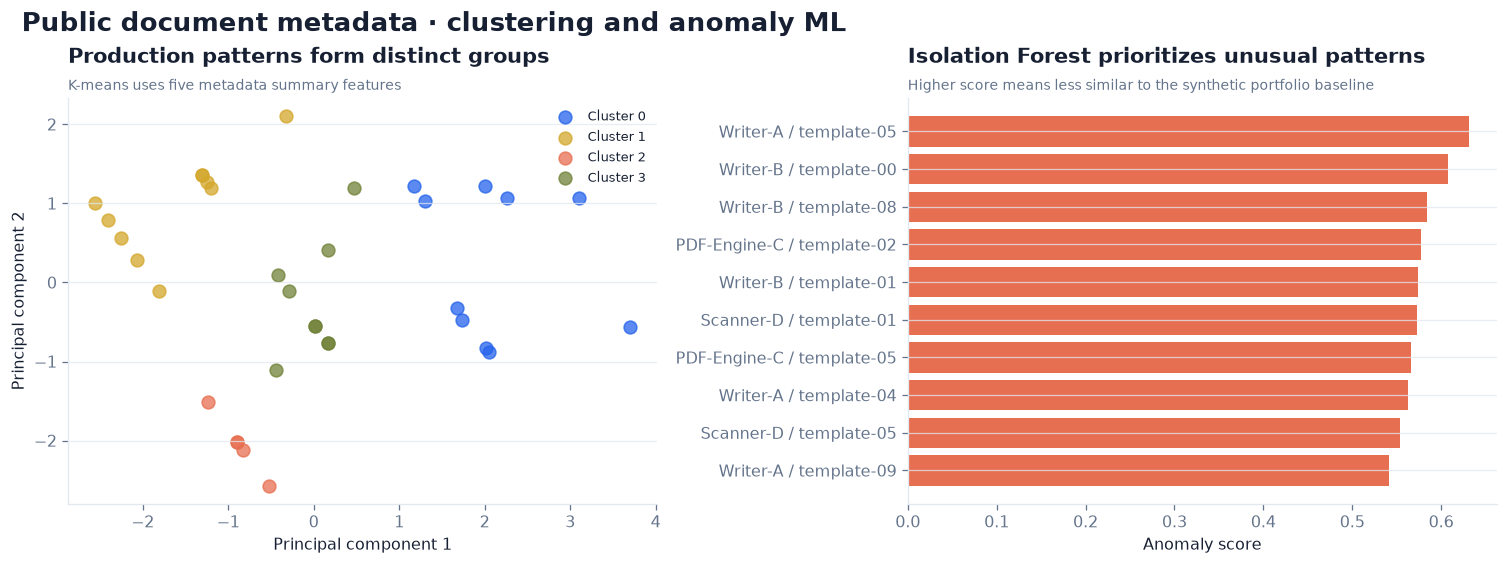

In [4]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingRegressor, IsolationForest, RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, f1_score, mean_absolute_error, r2_score, roc_auc_score, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED = globals().get("SEED", 88)

PALETTE = {
    "blue": "#2563EB",
    "gold": "#D4A72C",
    "orange": "#E76F51",
    "olive": "#708238",
    "pink": "#C65D86",
    "ink": "#172033",
    "muted": "#64748B",
    "grid": "#E2E8F0",
    "paper": "#FFFFFF",
}

plt.rcParams.update({
    "figure.facecolor": PALETTE["paper"],
    "axes.facecolor": PALETTE["paper"],
    "axes.edgecolor": PALETTE["grid"],
    "axes.labelcolor": PALETTE["ink"],
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "font.size": 10,
    "text.color": PALETTE["ink"],
    "xtick.color": PALETTE["muted"],
    "ytick.color": PALETTE["muted"],
    "grid.color": PALETTE["grid"],
    "grid.linewidth": 0.8,
})

def polish_axis(ax, title, subtitle, xlabel="", ylabel=""):
    ax.set_title(title, loc="left", pad=22)
    ax.text(0, 1.02, subtitle, transform=ax.transAxes, color=PALETTE["muted"], fontsize=9)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.75)
    ax.spines[["top", "right"]].set_visible(False)

def compare_binary_models(features, labels):
    x_train, x_test, y_train, y_test = train_test_split(
        features,
        labels,
        test_size=0.30,
        random_state=SEED,
        stratify=labels,
    )
    models = {
        "Logistic regression": make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=1200, class_weight="balanced", random_state=SEED),
        ),
        "Random forest": RandomForestClassifier(
            n_estimators=140,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=1,
        ),
    }
    rows, probabilities, fitted = [], {}, {}
    for name, model in models.items():
        model.fit(x_train, y_train)
        probability = model.predict_proba(x_test)[:, 1]
        prediction = (probability >= 0.5).astype(int)
        rows.append({
            "model": name,
            "roc_auc": roc_auc_score(y_test, probability),
            "average_precision": average_precision_score(y_test, probability),
            "f1_at_0_5": f1_score(y_test, prediction, zero_division=0),
        })
        probabilities[name] = probability
        fitted[name] = model
    return pd.DataFrame(rows).set_index("model"), fitted, probabilities, y_test

document_features = production_patterns[["documents", "timezones", "author_fields", "median_revisions", "metadata_hygiene_score"]]
document_scaled = StandardScaler().fit_transform(document_features)
document_model = IsolationForest(n_estimators=180, contamination=0.15, random_state=SEED, n_jobs=1)
production_patterns["anomaly_score"] = -document_model.fit(document_scaled).score_samples(document_scaled)
production_patterns["behavior_cluster"] = KMeans(n_clusters=4, n_init=30, random_state=SEED).fit_predict(document_scaled)
document_projection = PCA(n_components=2, random_state=SEED).fit_transform(document_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
colors = [PALETTE["blue"], PALETTE["gold"], PALETTE["orange"], PALETTE["olive"]]
for cluster_id, color in enumerate(colors):
    member = production_patterns["behavior_cluster"] == cluster_id
    axes[0].scatter(document_projection[member, 0], document_projection[member, 1], s=64, alpha=0.75, color=color, label=f"Cluster {cluster_id}")
axes[0].legend(frameon=False, fontsize=8)
polish_axis(axes[0], "Production patterns form distinct groups", "K-means uses five metadata summary features", "Principal component 1", "Principal component 2")

top_anomalies = production_patterns.nlargest(10, "anomaly_score").sort_values("anomaly_score")
anomaly_labels = top_anomalies["creator_tool"] + " / " + top_anomalies["template_id"]
axes[1].barh(anomaly_labels, top_anomalies["anomaly_score"], color=PALETTE["orange"])
polish_axis(axes[1], "Isolation Forest prioritizes unusual patterns", "Higher score means less similar to the synthetic portfolio baseline", "Anomaly score", "")
fig.suptitle("Public document metadata · clustering and anomaly ML", fontsize=16, fontweight="bold", x=0.01, ha="left")

cluster_summary = production_patterns.groupby("behavior_cluster").agg(patterns=("template_id", "count"), mean_documents=("documents", "mean"), mean_hygiene=("metadata_hygiene_score", "mean"), mean_anomaly=("anomaly_score", "mean"))
print(cluster_summary.round(3).to_string())
print("\nAnalyst takeaways:")
print(f"- The top 15% most unusual patterns are review candidates, not authorship claims.")
print(f"- Cluster {int(cluster_summary['mean_anomaly'].idxmax())} is least typical of the generated portfolio.")
print("- Hash or redact direct identifiers and retain source provenance before adapting this workflow.")


## Checks

Run deterministic integrity and reasonableness checks.


In [5]:
assert documents["document_id"].is_unique
assert ranked_patterns["documents"].sum() == document_count
assert ranked_patterns["metadata_hygiene_score"].between(0, 1).all()
print("Checks passed; metadata patterns do not establish authorship.")


Checks passed; metadata patterns do not establish authorship.


## Next Steps

- Hash or redact direct identifiers before analysis.
- Record document provenance and publication timestamps.
